In [1]:
import os
import sys

import warnings
warnings.filterwarnings("ignore")

from importlib import reload

import numpy as np
from lmfit import minimize, Parameters, fit_report, Model
from tqdm import tqdm

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update(
    {
        'text.usetex': False,
        'font.family': 'stixgeneral',
        'mathtext.fontset': 'stix',
    }
)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['image.origin'] = 'lower'
# plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.family"] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Tahoma', 'Verdana', 'Lucida Grande', 'DejaVu Sans']

cmap = matplotlib.cm.get_cmap('magma_r')
colors = ["white", "white", "white"]+[cmap(i/100) for i in range(100)]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap2 = matplotlib.colors.LinearSegmentedColormap.from_list("", ["lime","navajowhite", "dodgerblue"])
#from pfb_tools import DeconvolvePFB

from scipy import signal
from scipy.stats import median_abs_deviation
from scipy.interpolate import make_lsq_spline

import json
from copy import deepcopy
import chime_frb_constants as const
import fitburst as fb
from scipy.interpolate import interp2d

import seaborn as sns
sns.set_context('talk') 
sns.set(font_scale=1.8)
sns.set_palette('colorblind')
sns.set_style('ticks')

from baseband_analysis.core.signal import get_main_peak_lim, tiedbeam_baseband_to_power
from baseband_analysis.core.bbdata import BBData
from baseband_analysis.analysis.snr import get_snr, get_profile
from baseband_analysis.core.sampling import scrunch
from baseband_analysis.core.dedispersion import coherent_dedisp, incoherent_dedisp
from baseband_analysis.analysis.polarization import get_burst_envelope

from chime_frb_constants import FPGA_DELTA_FREQ_MHZ, K_DM

import chime_frb_api
master = chime_frb_api.frb_master.FRBMaster(base_url = "https://frb.chimenet.ca/frb-master")
master.API.authorize()
auth = {"Authorization": master.API.access_token}

import utilities.upchan_spec
from utilities.upchan_spec import *


In [2]:
names = np.array([
'zach',
'whitney',
'oran',
'isha',
'wilhelm',
'phineas',
'freya',
'johndoeII'
'hamilton',
'mahi',
'chromatica',
'casey',
])

chimeids = np.array([
'210456524',
'215063905',
'224263996',
'252069198',
'253635173',
'274819243',
'278720455',
'311723353'
'318353610',
'354049284',
'356959136',
'362593221'
])

dir_paths = np.array([
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/02/07/astro_210456524/run_pre_apr2025',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/03/10/astro_215063905/run_pre_apr2025',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/05/06/astro_224263996/run_pre_apr2025',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/11/13/astro_252069198/run_pre_apr2025',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/12/03/astro_253635173/run_pre_apr2025',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/03/07/astro_274819243',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/03/25/astro_278720455',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/08/14/astro_311723353',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/09/13/astro_318353610',
'/arc/projects/chime_frb/data/chime/baseband/processed/2024/01/22/astro_354049284',
'/arc/projects/chime_frb/data/chime/baseband/processed/2024/02/03/astro_356959136',
'/arc/projects/chime_frb/data/chime/baseband/processed/2024/02/29/astro_362593221'
])

file_paths = np.array([
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/02/07/astro_210456524/run_pre_apr2025/singlebeam_210456524.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/03/10/astro_215063905/run_pre_apr2025/singlebeam_215063905.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/05/06/astro_224263996/run_pre_apr2025/singlebeam_224263996.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/11/13/astro_252069198/run_pre_apr2025/singlebeam_252069198.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/12/03/astro_253635173/run_pre_apr2025/singlebeam_253635173.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/03/07/astro_274819243/singlebeam_274819243.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/03/25/astro_278720455/singlebeam_278720455.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/08/14/astro_311723353/singlebeam_311723353.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/09/13/astro_318353610/singlebeam_318353610.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2024/01/22/astro_354049284/singlebeam_354049284.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2024/02/03/astro_356959136/singlebeam_356959136.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2024/02/29/astro_362593221/singlebeam_362593221.h5'
])

dms_opt = np.array([
262.368,
462.174,
396.882,
411.568,
602.346,
610.274,
912.400,
696.506,
518.799,
960.128,
272.664,
491.207,
])

In [3]:
event_idx = 0
eventname = names[event_idx]
downsample_factor = 1


In [5]:
bbdata = BBData.from_file('/arc/projects/chime_frb/data/chime/baseband/processed/2022/02/07/astro_210456524/run_pre_apr2025/singlebeam_210456524.h5')



In [6]:
bbdata.attrs.create('DM', 0.)

AttributeError: 'MemAttrs' object has no attribute 'create'

In [115]:
bbdata.attrs.__delitem__('DM')


In [118]:
print(bbdata.attrs.get('DM'))

None


In [4]:
import utilities.kenzie_funcs
reload(utilities.kenzie_funcs)
from utilities.kenzie_funcs import *

import utilities.scint_funcs
reload(utilities.scint_funcs)
from utilities.scint_funcs import *

reload(utilities.upchan_spec)
from utilities.upchan_spec import *

In [5]:
diagnostic_plots_direc = '/arc/home/jfaber/baseband_morphologies/chime_dsa_codetections/scintillation'


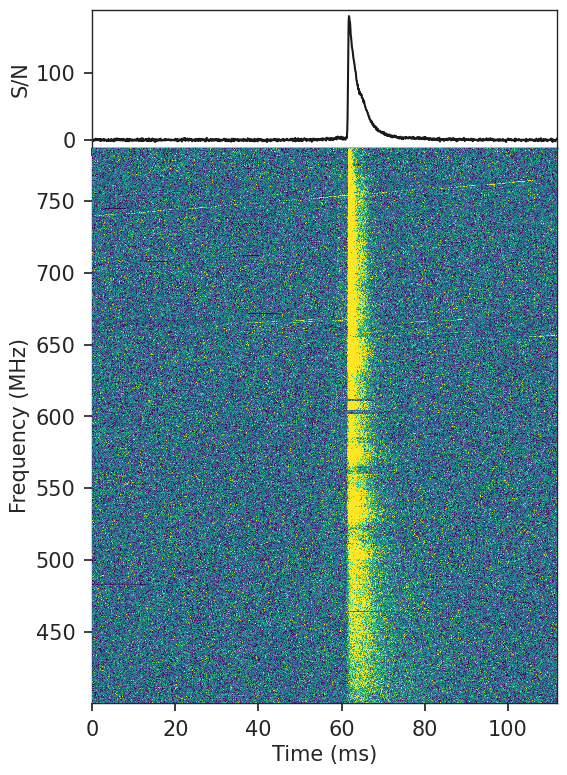

262.368 262.368 0
No NaNs to mask


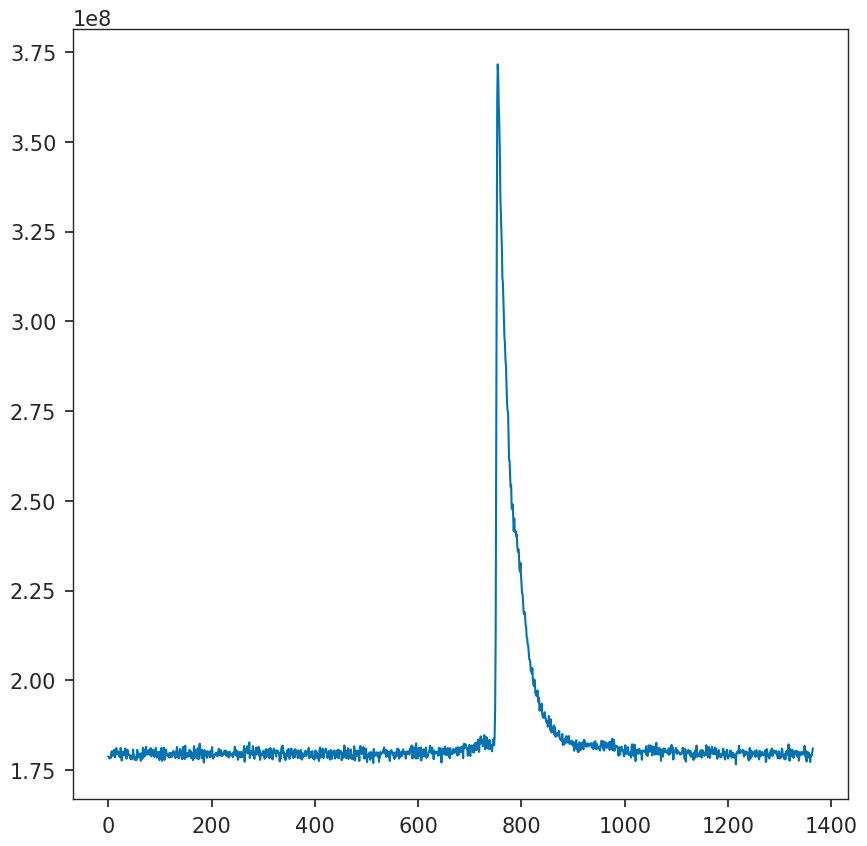

Please define the time bin range to keep (beginbin,endbin):  600, 1200


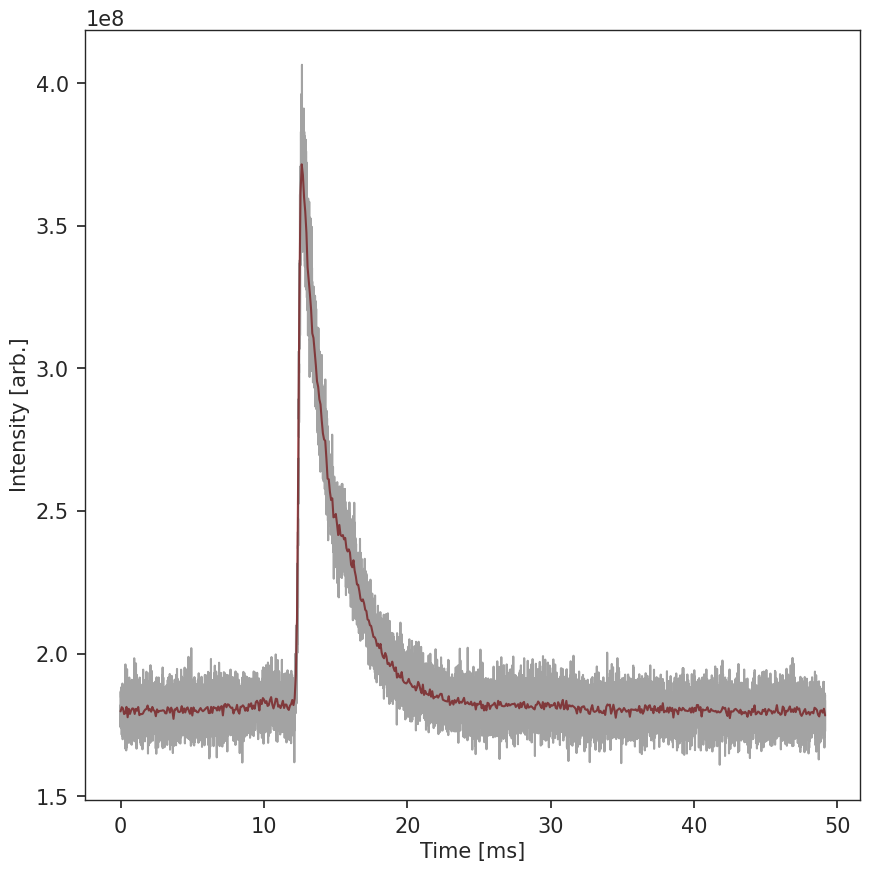

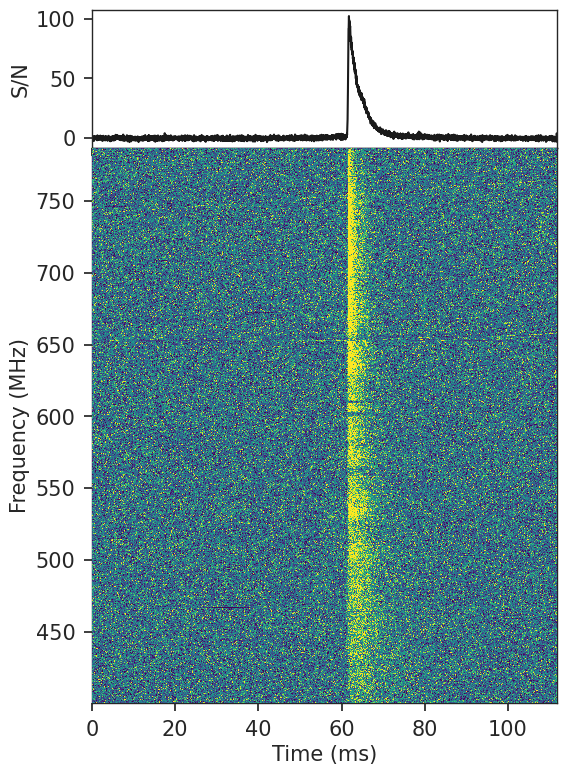

262.368 262.368 0
No NaNs to mask


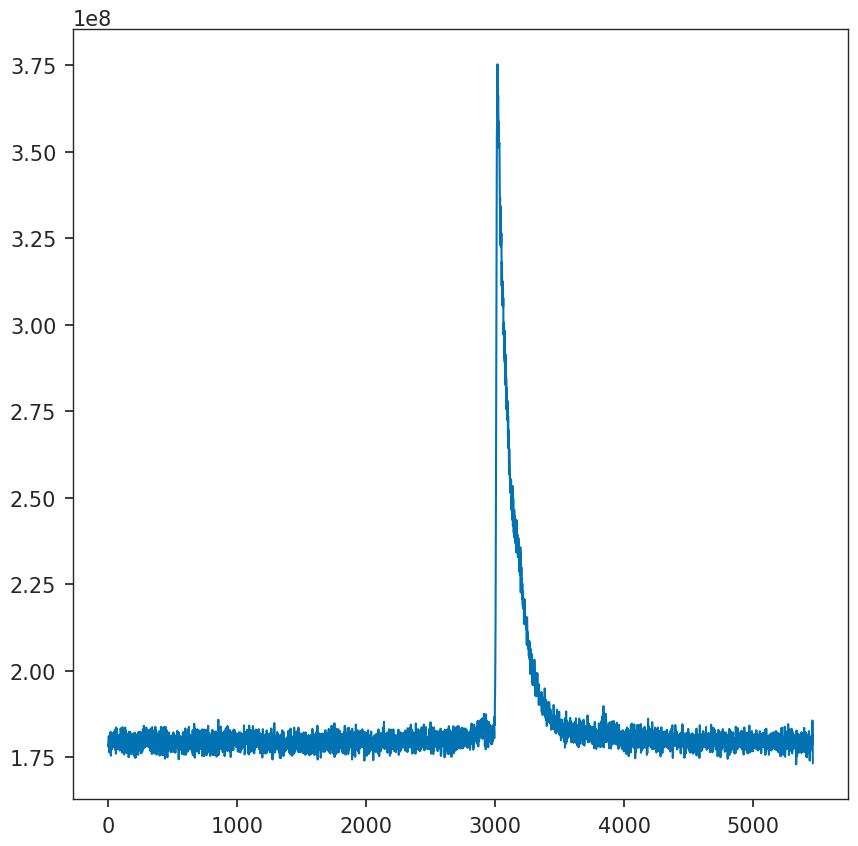

Please define the time bin range to keep (beginbin,endbin):  2700, 4200


*** Determining the burst extent in frequency ***


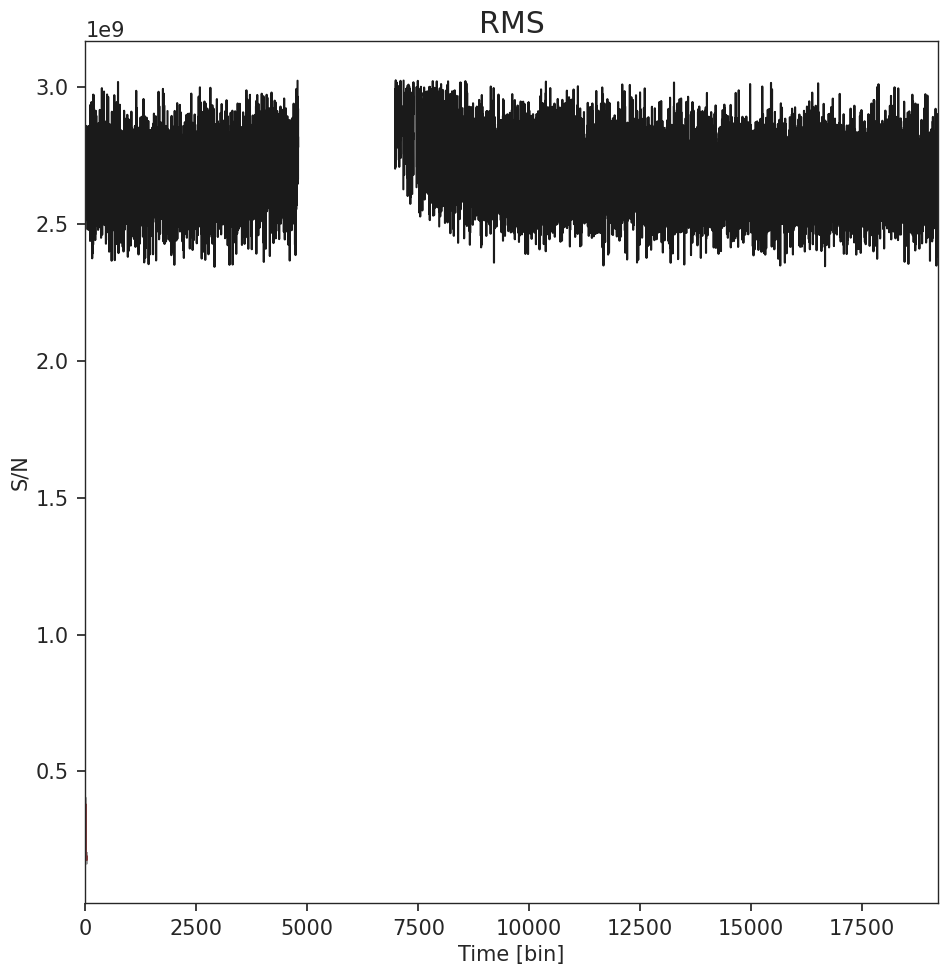

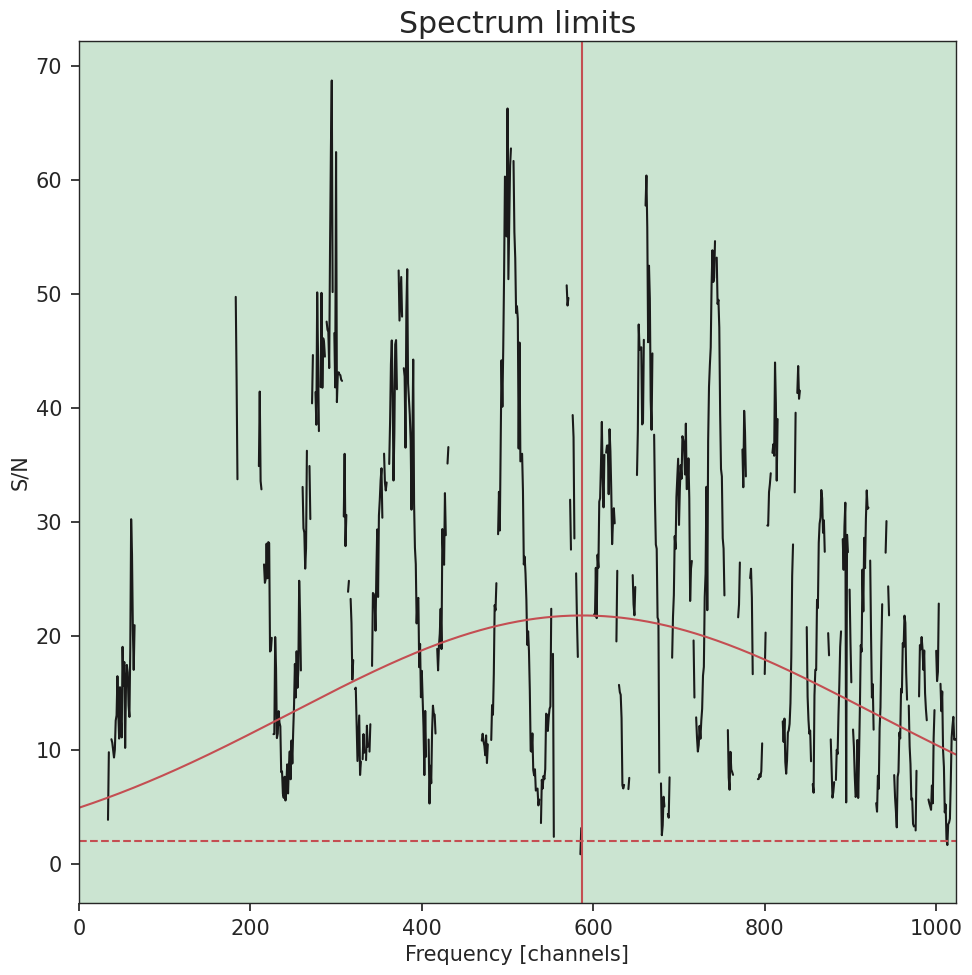

(0, 1024)
*** Determining the burst width ***
*** Upchannelising to fftsize 64, downfreq 1 ***
(71, 155)


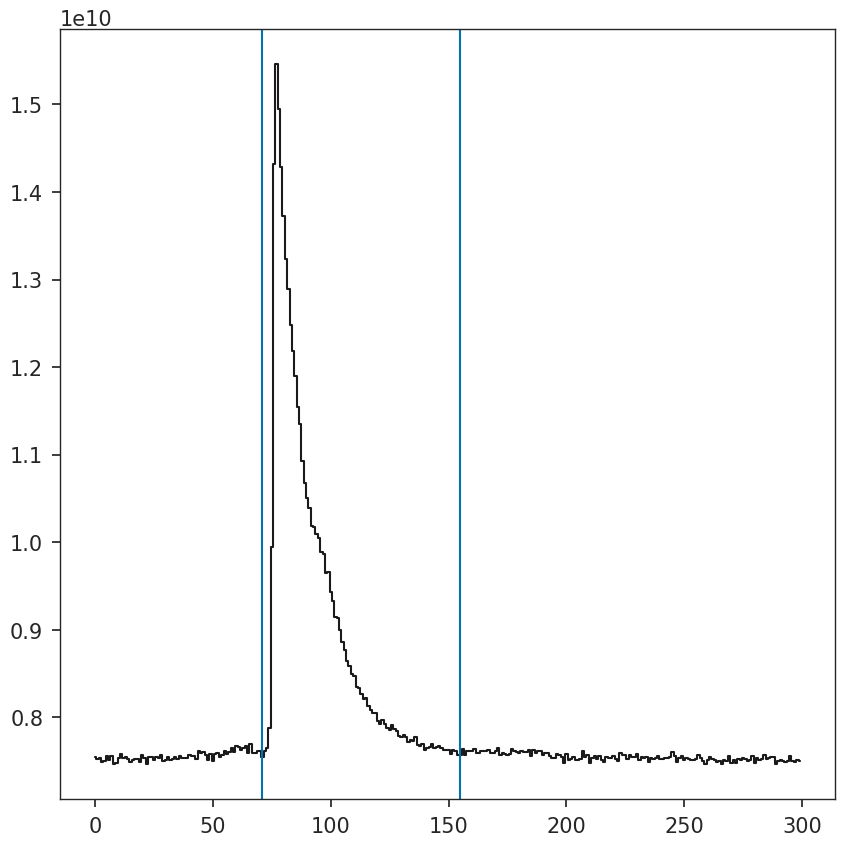

In [65]:
#I_upchan_ds, data_dedisp_masked_upchan_ds[1], data_dedisp_masked_upchan_ds[2], model_ds, inds, upchan_lims, fftsize
(
    I_upchan_ds,
    freq_upchan,
    freqid_upchan,
    scallop_model_ds,
    scallop_inds,
    upchan_lims,
    fftsize,
    downfreq
) = make_scint_input(
    names[event_idx],
    chimeids[event_idx],
    dms_opt[event_idx],
    file_paths[event_idx],
    diagnostic_plots_direc=diagnostic_plots_direc,
    fftsize=64,
    downfreq=1,
    speclims=None,
    interactive=True
)
 


In [78]:
print(I_upchan_ds.shape)
print(freq_upchan.shape)
print(freqid_upchan.shape)
print(scallop_model_ds.shape)
print(upchan_lims)
upchan_lims = (71, 155) #broaden a little bit

(65536, 300)
(65536,)
(65536,)
(65536,)
(71, 155)


10
*** Normalising per channel and creating burst spectra***
70
[-- -- -- ... -1.6178404393940582e-08 -8.514949634275126e-09
 3.3660658704803836e-09]
4.489697e-11
Frequency resolution is 0.00610 MHz


100%|██████████| 3276/3276 [00:01<00:00, 1977.71it/s]


Could not fit a Lorentzian
Frequency resolution is 0.00610 MHz


100%|██████████| 3276/3276 [00:01<00:00, 1910.15it/s]


Could not fit a Lorentzian
beg,end 0 10922
Frequency resolution is 0.00610 MHz


...

Could not fit a Lorentzian
beg,end 43688 54610
Frequency resolution is 0.00610 MHz


100%|██████████| 1638/1638 [00:00<00:00, 8856.28it/s]


Could not fit a Lorentzian
beg,end 54610 65532
Frequency resolution is 0.00610 MHz


100%|██████████| 1638/1638 [00:00<00:00, 8918.83it/s]


Could not fit a Lorentzian


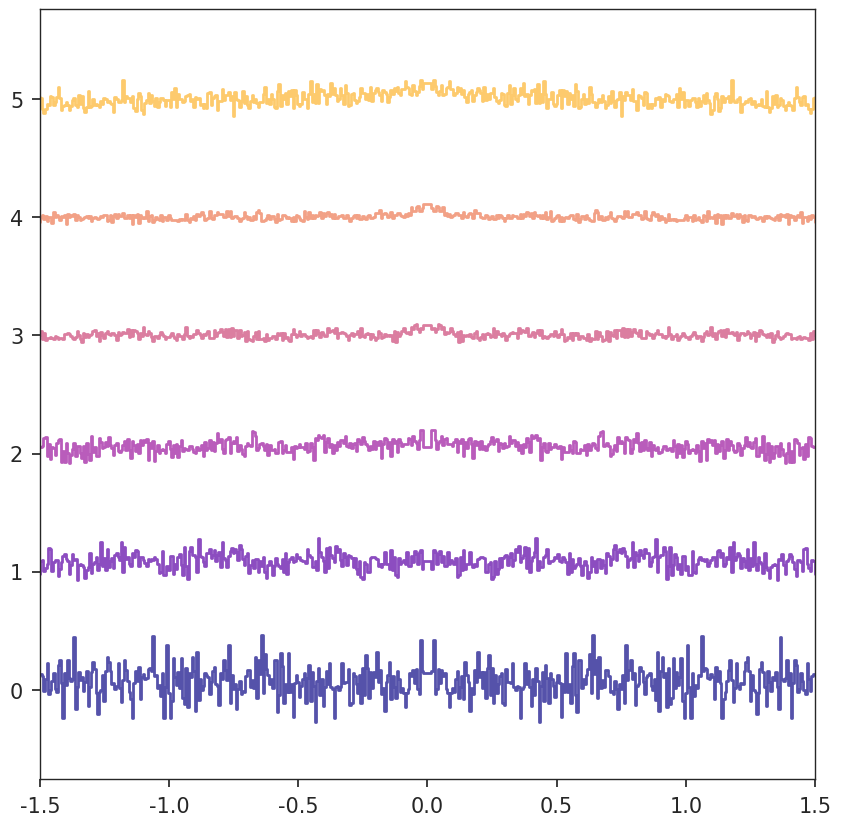

In [82]:
import utilities.kenzie_funcs
reload(utilities.kenzie_funcs)
from utilities.kenzie_funcs import *

import utilities.scint_funcs
reload(utilities.scint_funcs)
from utilities.scint_funcs import *

reload(utilities.upchan_spec)
from utilities.upchan_spec import *

(
    acf_res, #acf_res[0],
    acf_peak_res0, #acf_peak_res[0],
    acf_peak_res1, #acf_peak_res[1],
    acf_subs,
    acf_peak_subs,
    fcents_subs,
    lags_subs,
    submask,
    submask_peak,
    spec_lens,
    spec_lens_peak,
) = run_scint_pipe(
    names[event_idx],
    I_upchan_ds,
    freq_upchan,
    freqid_upchan,
    scallop_model_ds,
    scallop_inds,
    upchan_lims,
    fftsize,
    downfreq,
    diagnostic_plot=diagnostic_plots_direc,
    subbands=6,
    peak_only=False,
    maxlag=20,
    maxlag_subs=10,
    snsubband=False,
)


[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 185
    # data points      = 326
    # variables        = 5
    chi-square         = 2.94916324
    reduced chi-square = 0.00918742
    Akaike info crit   = -1523.95254
    Bayesian info crit = -1505.01806
[[Variables]]
    gamma1:  4.96335090 +/- 2.2215e+10 (447574941832.31%) (init = 1)
    m1:     -1.5500e-05 +/- 66774.0033 (430801835025.30%) (init = 1)
    gamma2:  0.02185131 +/- 0.00876593 (40.12%) (init = 0.2)
    m2:      0.24023981 +/- 0.04388869 (18.27%) (init = 1)
    c:       0.02110407 +/- 2.07067790 (9811.75%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(m1, c)      = +1.0000
    C(gamma1, c)  = -0.9993
    C(gamma1, m1) = -0.9992
    C(gamma2, m2) = -0.8720
    C(m1, m2)     = -0.1009
    C(m2, c)      = -0.1008
None
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 79
    # data points      = 326
    # variables        = 5
    chi-square      

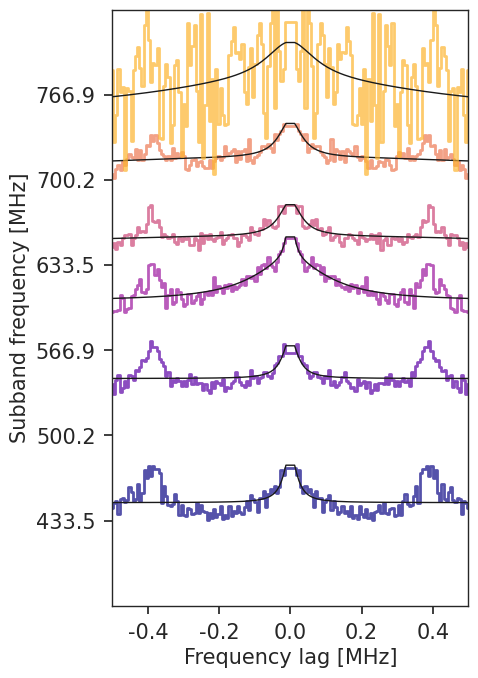

ValueError: NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan-in-my-fit-what-can-i-do for more information.

<Figure size 1000x1000 with 0 Axes>

In [83]:
import utilities.kenzie_funcs
reload(utilities.kenzie_funcs)
from utilities.kenzie_funcs import *

import utilities.scint_funcs
reload(utilities.scint_funcs)
from utilities.scint_funcs import *

reload(utilities.upchan_spec)
from utilities.upchan_spec import *

(
    f_cents, 
    sub_scint, 
    sub_scint_uncert,
    onescint   
) = fit_subband_acfs(
    names[event_idx],
    acf_subs, 
    fcents_subs, 
    lags_subs, 
    fftsize, 
    downfreq,
    submask,
    spec_lens,
    freq_upchan,
    numsubs=6, 
    numlorentz=2, 
    lagrange_for_fits=None,
    offset=1,
    diagnostic_plot=diagnostic_plots_direc, 
    xlim=0.5
)
    
    